# **Comparative Study of Learning Rates on Neural Network Training using Loss and Accuracy Curves**

# IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# LOAD DATASET

In [ ]:
df = pd.read_csv("/content/spam_or_not_spam.csv")
df.dropna(inplace=True)

X = df['email']
y = df['label']

# TEXT VECTORIZATION (TF-IDF)

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer.fit_transform(X).toarray()

# ACTIVATION FUNCTIONS

In [ ]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# MODEL TRAINING FUNCTION

In [ ]:
def train_model(X_train, y_train, X_test, y_test, lr):

    np.random.seed(42)

    input_size = X_train.shape[1]
    hidden1 = 64
    hidden2 = 32
    output_size = 1
    epochs = 200

    W1 = np.random.randn(input_size, hidden1) * 0.01
    b1 = np.random.randn(1, hidden1) * 0.01

    W2 = np.random.randn(hidden1, hidden2) * 0.01
    b2 = np.random.randn(1, hidden2) * 0.01

    W3 = np.random.randn(hidden2, output_size) * 0.01
    b3 = np.random.randn(1, output_size) * 0.01

    train_loss, train_acc = [], []
    test_loss, test_acc = [], []

    y_train = y_train.values.reshape(-1, 1)
    y_test = y_test.values.reshape(-1, 1)

    for epoch in range(epochs):

        # ===== FORWARD (TRAIN) =====
        Z1 = np.dot(X_train, W1) + b1
        A1 = relu(Z1)

        Z2 = np.dot(A1, W2) + b2
        A2 = relu(Z2)

        Z3 = np.dot(A2, W3) + b3
        A3 = sigmoid(Z3)

        loss = -np.mean(y_train * np.log(A3 + 1e-9) +
                        (1 - y_train) * np.log(1 - A3 + 1e-9))
        train_loss.append(loss)

        predictions = (A3 >= 0.5).astype(int)
        acc = accuracy_score(y_train, predictions)
        train_acc.append(acc)

        # ===== BACKPROPAGATION =====
        dZ3 = A3 - y_train
        dW3 = np.dot(A2.T, dZ3) / len(X_train)
        db3 = np.sum(dZ3, axis=0, keepdims=True) / len(X_train)

        dA2 = np.dot(dZ3, W3.T)
        dZ2 = dA2 * relu_derivative(Z2)
        dW2 = np.dot(A1.T, dZ2) / len(X_train)
        db2 = np.sum(dZ2, axis=0, keepdims=True) / len(X_train)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * relu_derivative(Z1)
        dW1 = np.dot(X_train.T, dZ1) / len(X_train)
        db1 = np.sum(dZ1, axis=0, keepdims=True) / len(X_train)

        # ===== UPDATE WEIGHTS =====
        W3 -= lr * dW3
        b3 -= lr * db3
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        # ===== DISPLAY TRAINING PROGRESS =====
        if epoch % 20 == 0:
            print(f"Epoch {epoch}: Loss={loss:.4f}, Accuracy={acc:.4f}")

        # ===== FORWARD (TEST) =====
        Z1_t = np.dot(X_test, W1) + b1
        A1_t = relu(Z1_t)

        Z2_t = np.dot(A1_t, W2) + b2
        A2_t = relu(Z2_t)

        Z3_t = np.dot(A2_t, W3) + b3
        A3_t = sigmoid(Z3_t)

        t_loss = -np.mean(y_test * np.log(A3_t + 1e-9) +
                          (1 - y_test) * np.log(1 - A3_t + 1e-9))
        test_loss.append(t_loss)

        t_pred = (A3_t >= 0.5).astype(int)
        test_acc.append(accuracy_score(y_test, t_pred))

    # ===== FINAL TEST METRICS =====
    accuracy = accuracy_score(y_test, t_pred)
    precision = precision_score(y_test, t_pred)
    recall = recall_score(y_test, t_pred)
    f1 = f1_score(y_test, t_pred)

    print("\nFinal Test Metrics (LR =", lr, ")")
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    # ===== CONFUSION MATRIX =====
    cm = confusion_matrix(y_test, t_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"Confusion Matrix (LR={lr})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return train_loss, train_acc, test_loss, test_acc

# TRAIN-TEST SPLITS

In [ ]:
learning_rates = [0.01, 0.005, 0.001]

splits = [
    (0.2, "80/20 Split"),
    (0.3, "70/30 Split")
]

# MODEL EXECUTION & CURVE VISUALIZATION


80/20 Split

Training with Learning Rate = 0.01
Epoch 0: Loss=0.6968, Accuracy=0.1663
Epoch 20: Loss=0.6751, Accuracy=0.8337
Epoch 40: Loss=0.6556, Accuracy=0.8337
Epoch 60: Loss=0.6379, Accuracy=0.8337
Epoch 80: Loss=0.6218, Accuracy=0.8337
Epoch 100: Loss=0.6073, Accuracy=0.8337
Epoch 120: Loss=0.5942, Accuracy=0.8337
Epoch 140: Loss=0.5822, Accuracy=0.8337
Epoch 160: Loss=0.5714, Accuracy=0.8337
Epoch 180: Loss=0.5615, Accuracy=0.8337

Final Test Metrics (LR = 0.01 )
Accuracy : 0.8333333333333334
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


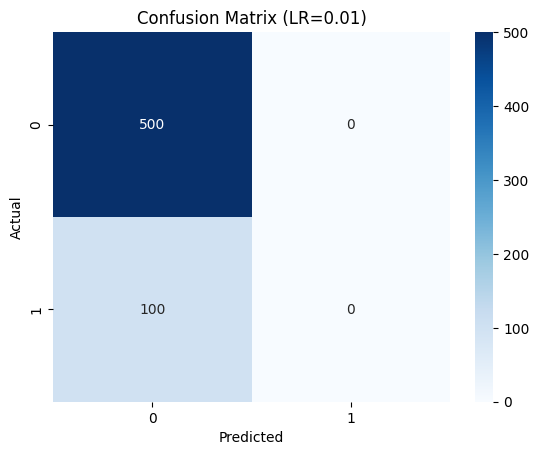


Training with Learning Rate = 0.005
Epoch 0: Loss=0.6968, Accuracy=0.1663
Epoch 20: Loss=0.6857, Accuracy=0.8337
Epoch 40: Loss=0.6751, Accuracy=0.8337
Epoch 60: Loss=0.6651, Accuracy=0.8337
Epoch 80: Loss=0.6556, Accuracy=0.8337
Epoch 100: Loss=0.6465, Accuracy=0.8337
Epoch 120: Loss=0.6379, Accuracy=0.8337
Epoch 140: Loss=0.6297, Accuracy=0.8337
Epoch 160: Loss=0.6219, Accuracy=0.8337
Epoch 180: Loss=0.6144, Accuracy=0.8337

Final Test Metrics (LR = 0.005 )
Accuracy : 0.8333333333333334
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


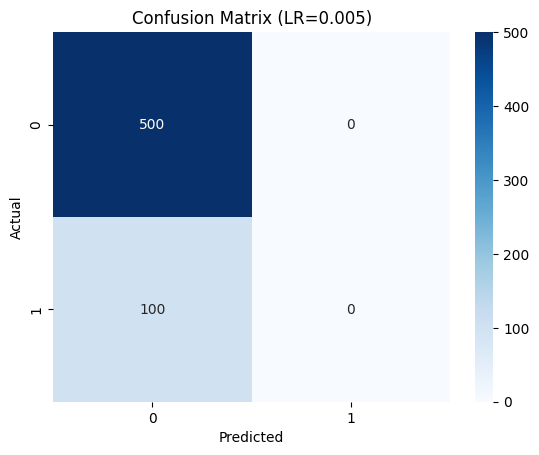


Training with Learning Rate = 0.001
Epoch 0: Loss=0.6968, Accuracy=0.1663
Epoch 20: Loss=0.6945, Accuracy=0.1663
Epoch 40: Loss=0.6923, Accuracy=0.8337
Epoch 60: Loss=0.6901, Accuracy=0.8337
Epoch 80: Loss=0.6879, Accuracy=0.8337
Epoch 100: Loss=0.6857, Accuracy=0.8337
Epoch 120: Loss=0.6835, Accuracy=0.8337
Epoch 140: Loss=0.6814, Accuracy=0.8337
Epoch 160: Loss=0.6793, Accuracy=0.8337
Epoch 180: Loss=0.6772, Accuracy=0.8337

Final Test Metrics (LR = 0.001 )
Accuracy : 0.8333333333333334
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


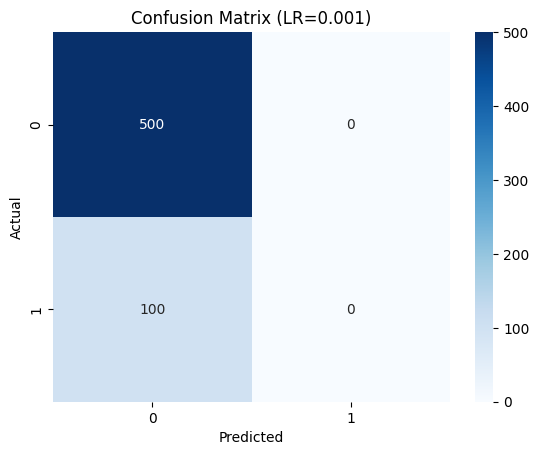

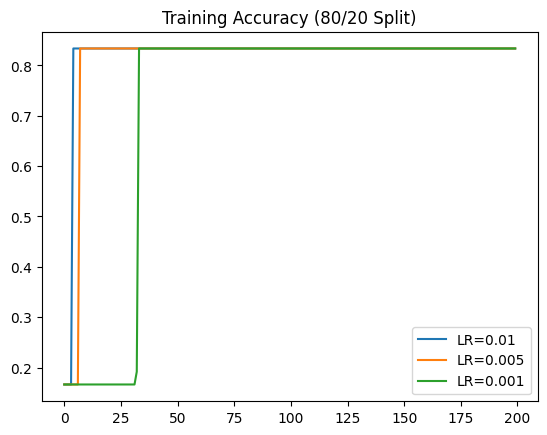

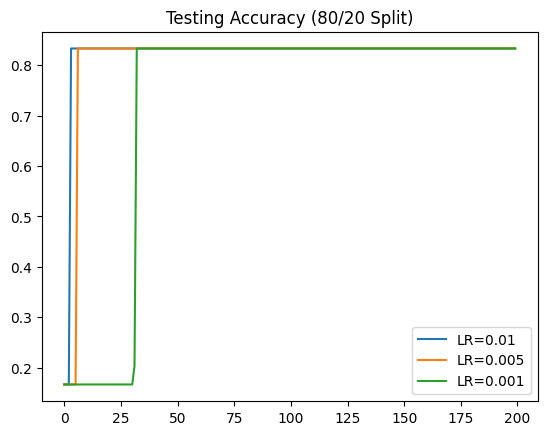

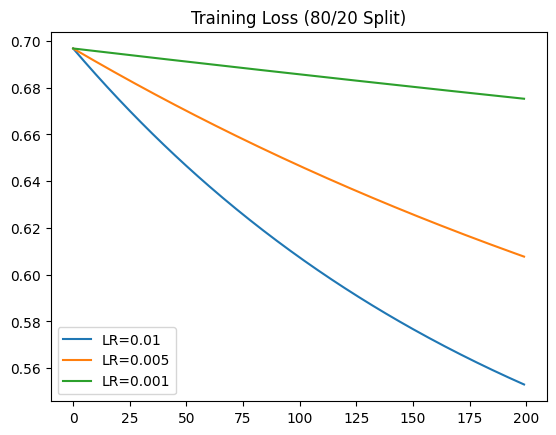

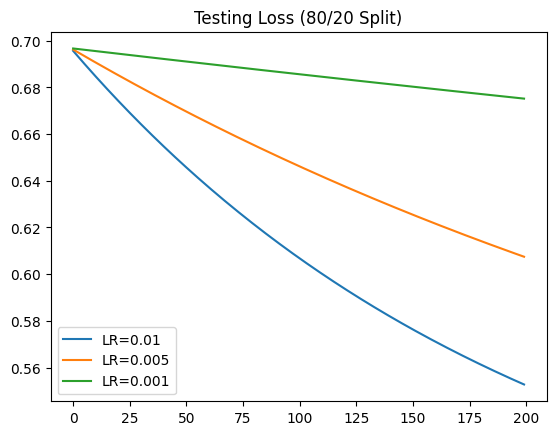


70/30 Split

Training with Learning Rate = 0.01
Epoch 0: Loss=0.6968, Accuracy=0.1620
Epoch 20: Loss=0.6746, Accuracy=0.8380
Epoch 40: Loss=0.6545, Accuracy=0.8380
Epoch 60: Loss=0.6364, Accuracy=0.8380
Epoch 80: Loss=0.6199, Accuracy=0.8380
Epoch 100: Loss=0.6051, Accuracy=0.8380
Epoch 120: Loss=0.5916, Accuracy=0.8380
Epoch 140: Loss=0.5793, Accuracy=0.8380
Epoch 160: Loss=0.5682, Accuracy=0.8380
Epoch 180: Loss=0.5581, Accuracy=0.8380


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Final Test Metrics (LR = 0.01 )
Accuracy : 0.8233333333333334
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


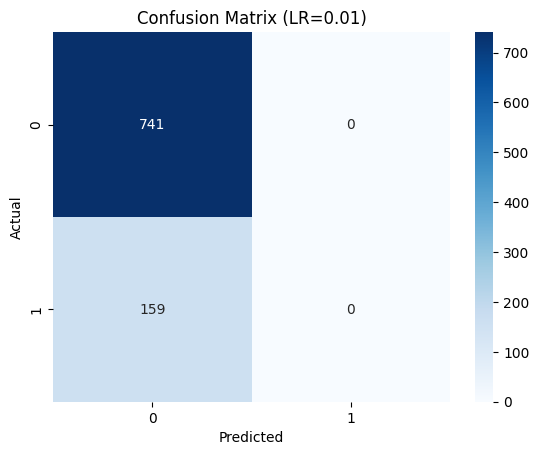


Training with Learning Rate = 0.005
Epoch 0: Loss=0.6968, Accuracy=0.1620
Epoch 20: Loss=0.6854, Accuracy=0.8380
Epoch 40: Loss=0.6746, Accuracy=0.8380
Epoch 60: Loss=0.6644, Accuracy=0.8380
Epoch 80: Loss=0.6546, Accuracy=0.8380
Epoch 100: Loss=0.6453, Accuracy=0.8380
Epoch 120: Loss=0.6364, Accuracy=0.8380
Epoch 140: Loss=0.6280, Accuracy=0.8380
Epoch 160: Loss=0.6200, Accuracy=0.8380
Epoch 180: Loss=0.6124, Accuracy=0.8380


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Final Test Metrics (LR = 0.005 )
Accuracy : 0.8233333333333334
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


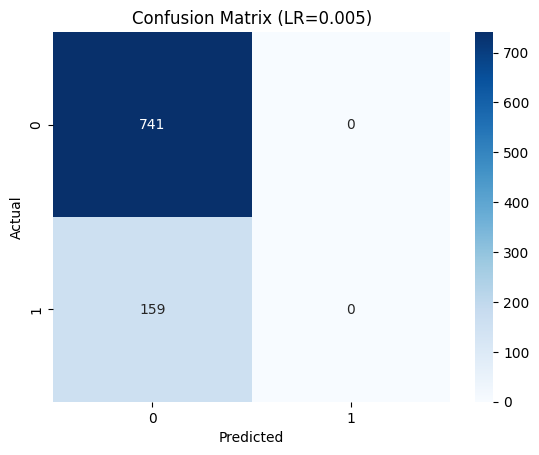


Training with Learning Rate = 0.001
Epoch 0: Loss=0.6968, Accuracy=0.1620
Epoch 20: Loss=0.6945, Accuracy=0.1620
Epoch 40: Loss=0.6922, Accuracy=0.8380
Epoch 60: Loss=0.6899, Accuracy=0.8380
Epoch 80: Loss=0.6877, Accuracy=0.8380
Epoch 100: Loss=0.6854, Accuracy=0.8380
Epoch 120: Loss=0.6832, Accuracy=0.8380
Epoch 140: Loss=0.6811, Accuracy=0.8380
Epoch 160: Loss=0.6789, Accuracy=0.8380
Epoch 180: Loss=0.6768, Accuracy=0.8380


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Final Test Metrics (LR = 0.001 )
Accuracy : 0.8233333333333334
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


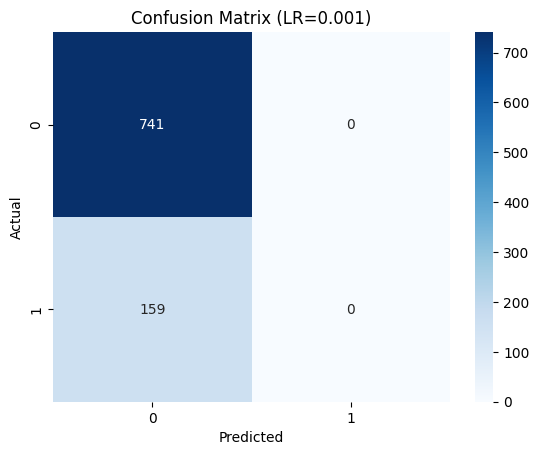

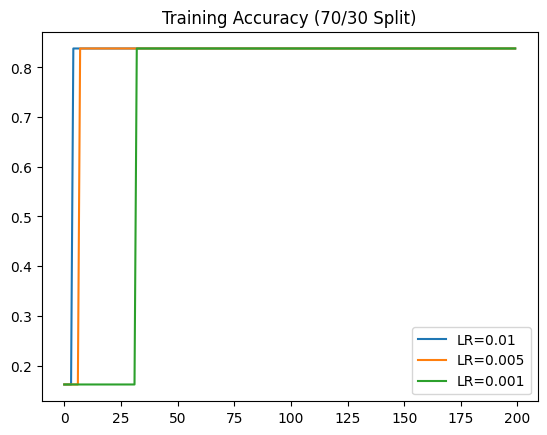

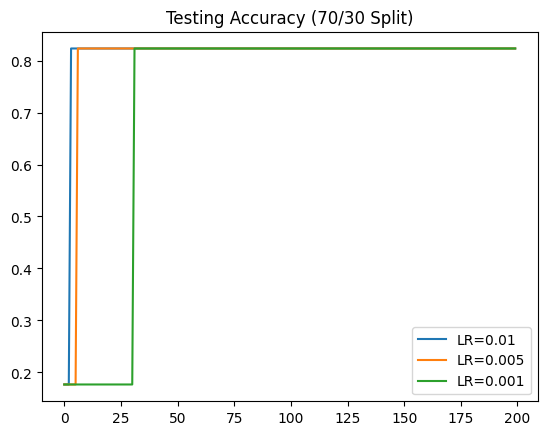

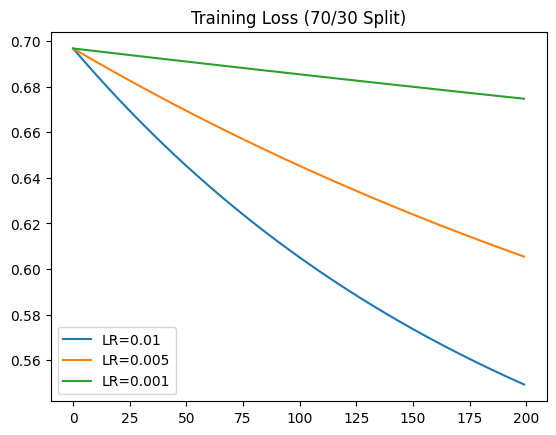

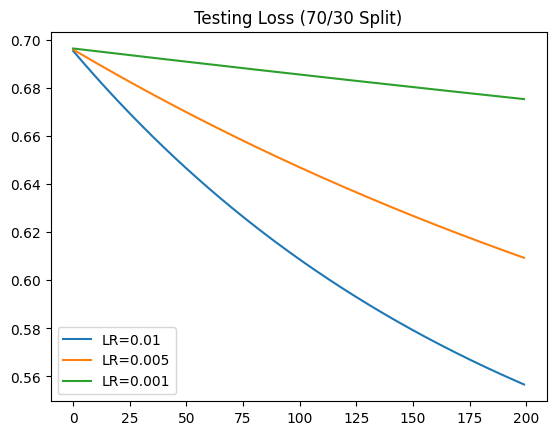

In [ ]:
for test_size, name in splits:

    print("\n==============================")
    print(name)
    print("==============================")

    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y, test_size=test_size, random_state=42
    )

    results = {}

    for lr in learning_rates:
        print(f"\nTraining with Learning Rate = {lr}")
        results[lr] = train_model(X_train, y_train, X_test, y_test, lr)

    # ==============================
    # PLOTS MUST BE INSIDE THIS LOOP
    # ==============================

    # Training Accuracy
    plt.figure()
    for lr in learning_rates:
        plt.plot(results[lr][1], label=f"LR={lr}")
    plt.title(f"Training Accuracy ({name})")
    plt.legend()
    plt.show()

    # Testing Accuracy
    plt.figure()
    for lr in learning_rates:
        plt.plot(results[lr][3], label=f"LR={lr}")
    plt.title(f"Testing Accuracy ({name})")
    plt.legend()
    plt.show()

    # Training Loss
    plt.figure()
    for lr in learning_rates:
        plt.plot(results[lr][0], label=f"LR={lr}")
    plt.title(f"Training Loss ({name})")
    plt.legend()
    plt.show()

    # Testing Loss
    plt.figure()
    for lr in learning_rates:
        plt.plot(results[lr][2], label=f"LR={lr}")
    plt.title(f"Testing Loss ({name})")
    plt.legend()
    plt.show()